# PFAM PROTEIN CLASSIFICATION

This notebook explores data in the PFAM Dataset, where each entry corresponds to a protein accompanied with additional information such as it's amino-acid sequence.

The final goals of this notebook are:
* To gather descriptive statistics on amino-acid sequences in the dataset
* Visualize key elements of the data
* Infer a good way to approach the problem

# IMPORTS

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
data = pd.read_csv('/home/rdi_aura/Data-Lakes-Practice/data/bronze/combined_data.csv')

Let's verify that the data has been correctly loaded:

In [14]:
data.head()

,family_id,sequence_name,family_accession,aligned_sequence,sequence
0,CPSase_L_D3,CARB_LACS1/422-540,PF02787.19,EKLFHAQDDRLFYIAEAF.RRG.Y.....TIE............EV...,EKLFHAQDDRLFYIAEAFRRGYTIEEVHELTKINLYYLDIVKQIVE...
1,SOCS_box,H2T4I2_TAKRU/225-262,PF07525.16,PPALMDLCA.......LAIQQ.HLGQQRHN.............QI....,PPALMDLCALAIQQHLGQQRHNQICNLPLPQPLRHYLL
2,Glug,Q8QNC2_ESV1K/681-707,PF07581.12,TNGRTGGVVGHAVG.........TDVTMCRNVA..TFT,TNGRTGGVVGHAVGTDVTMCRNVATFT
3,PepSY,A8MEK6_ALKOO/172-230,PF03413.19,VISEEQA.KKIA...........LEK.............I....N....,VISEEQAKKIALEKINGKVIKIELEYDDDTAEYEIEILKDGIKYEI...
4,PMSR,D1AKJ7_SEBTE/3-153,PF01625.21,EIILAGGCFWGVEAYF.QRLN........G..VI...KTEVGYTDG...,EIILAGGCFWGVEAYFQRLNGVIKTEVGYTDGVSENPTYKEVCSGT...


Now that the data is loaded, we shall try to explore it to see **whether it is suitable for learning**. If not, **why it isn't, and how to transform it** to make it suitable for learning.

Some questions that first come to mind are the following:

1.   Are classes well balanced? If not, how imbalanced are they? Are there imbalances from one data to another?
2.   How to efficiently compensate for these imbalances?
3.   How long are protein sequences on average ? In a real life scenarion, this would be a very important question to manage your GPU VRAM during training









# Class balance

As is, the data is the raw and transformations need to be applied to check for potential class imbalance. The PFAM dataset reportedly has entries from 17,930 output classes, therefore it seems likely that some will be over-represented and some under-represented.

This needs to be evaluated to develop a proper training protocol later on.

In [ ]:
def munge_data(data: pd.DataFrame):
  '''
  Munges data to extract key insights

  Paramaters:
  data (pd.DataFrame): Raw DataFrame after unpacking

  Returns:
  (pd.DataFrame): Munged data 
  '''
  munged_data = {
      'sample_count': data.shape[0], # Number of samples in the dataset
      'class_count': data['family_accession'].nunique(), # Number of unique classes (protein families)
      'min_samples_per_class': data.groupby('family_accession').size().min(), # Minimum number of samples in any class
      'max_samples_per_class': data.groupby('family_accession').size().max(), # Maximum number of samples in any class
      'mean_samples_per_class': data.groupby('family_accession').size().mean(), # Average number of samples per class
      'min_seq_length': data['sequence'].apply(len).min(), # Minimum sequence length
      'max_seq_length': data['sequence'].apply(len).max(), # Maximum sequence length
      'mean_seq_length': data['sequence'].apply(len).median() # Median sequence length
  }

  return pd.DataFrame([munged_data])

In [16]:
data_munged = munge_data(data)
data_munged

,sample_count,class_count,min_samples_per_class,max_samples_per_class,mean_samples_per_class,min_seq_length,max_seq_length,mean_seq_length
0,1339083,17929,1,4545,74.688103,4,2037,119.0


The above analysis confirms the following insights:

* **Output classes seem to be extremely imbalanced** when looking at min, max and mean number of samples per class
* **Sequence lengths look strongly unbalanced too**. However, with the median sequence length being 119, this tends to indicate that all context in most of the sequences can be captured with a model input_size of at least 119. In training, the goal will be to maximize this value to capture as much context as possible while staying in the range of available compute ressources.



Another point we want to verify is that amino-acid sequences are similarly distributed in terms of average length per class and samples per class between partitions.

Using seaborn, let's visualize these distributions to gain visual insight into the data:

# Class Distribution Plot

Text(0.5, 0.98, 'PFAM Class Distribution')

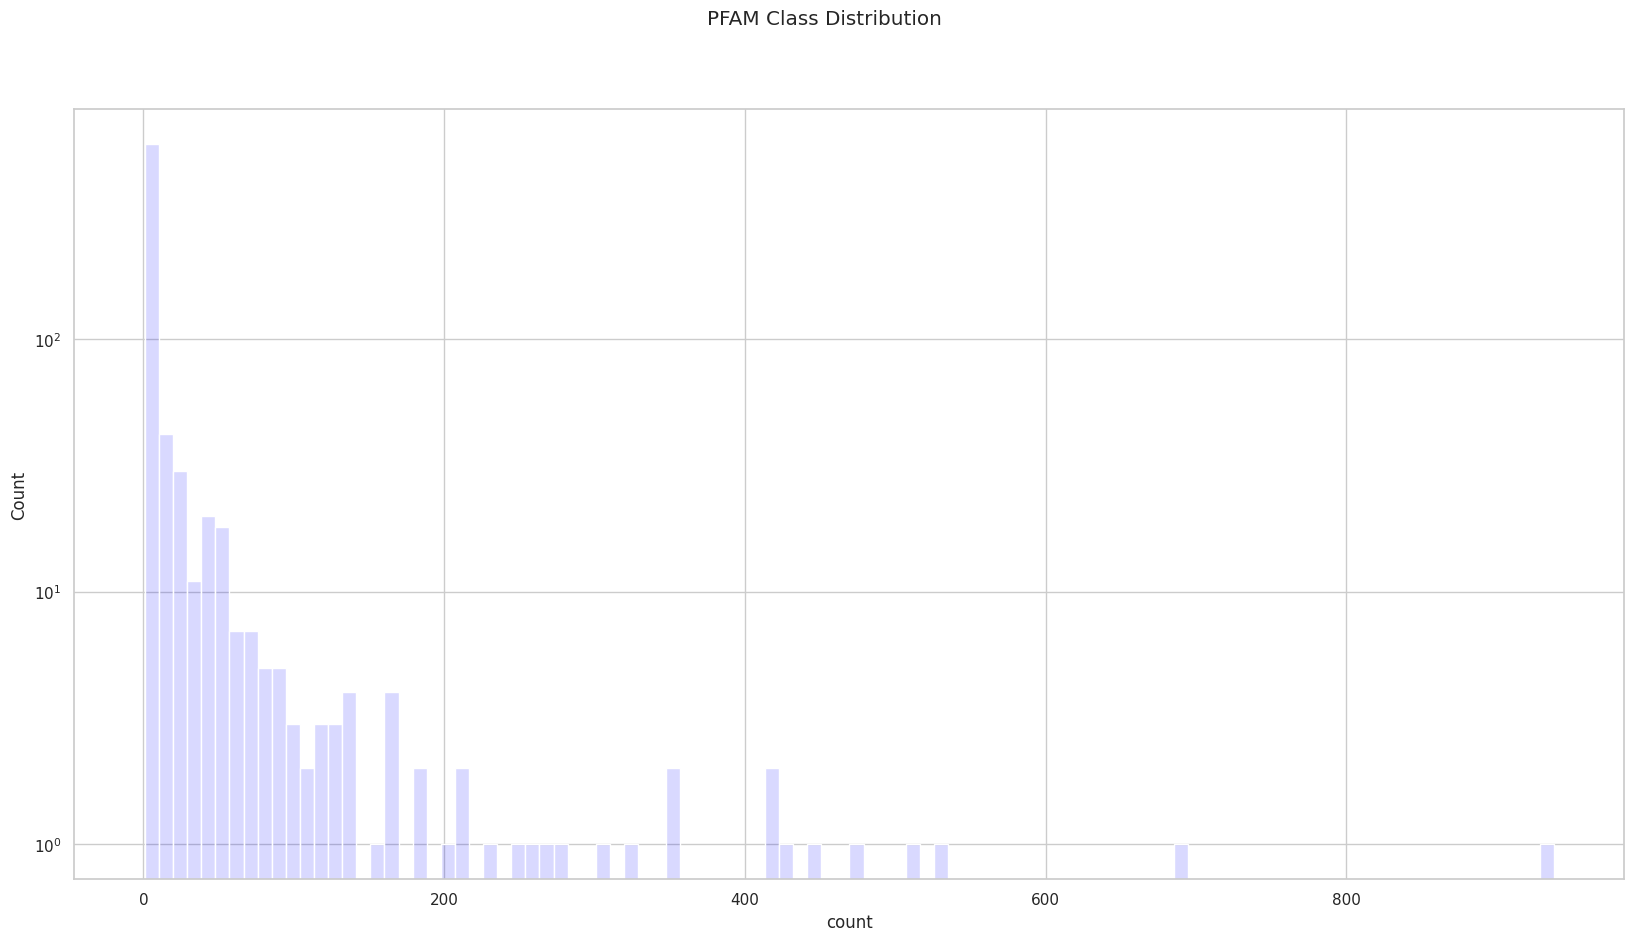

In [ ]:
# Visualize protein count per family size to visualize class imbalance

fig, ax = plt.subplots(figsize=(20,10))
colors = 'blue'
sns.set_theme(style="whitegrid")

family_size = data['family_id'].value_counts() # Count of samples (y-axis) for each family size (x-axis)
class_distribution = family_size.value_counts().sort_index() # Count of classes (y-axis) for each family size (x-axis) / Returns a new Series sorted by label

sns.histplot(data=class_distribution, bins=100, ax=ax, color=colors, kde=False, alpha=0.15)
plt.yscale('log')

fig.suptitle('PFAM Class Distribution')

In [19]:
class_distribution

count
1       507
2       938
3       692
4       533
5       472
       ... 
1908      1
1921      1
2199      1
2407      1
4545      1
Name: count, Length: 780, dtype: int64

Text(0.5, 1.0, 'Distribution of amino acids per sequence')

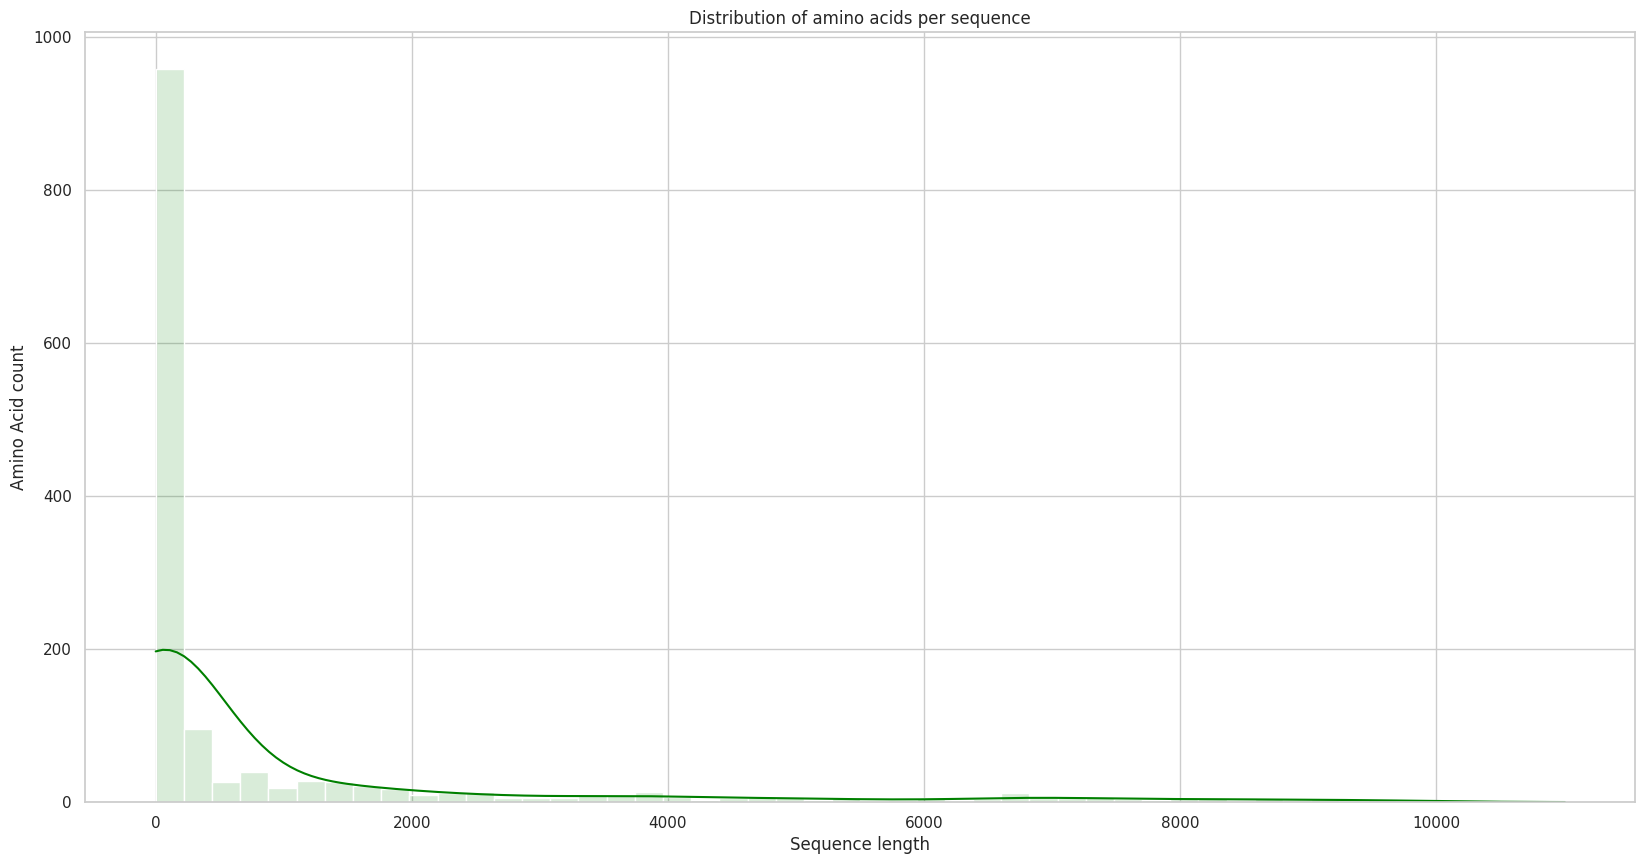

In [ ]:
# Visualize the distribution of sequence lenghts
fig, ax = plt.subplots(figsize=(20,10))
colors = 'green'

seq_lenghts = data['sequence'].apply(len).value_counts() # Count of sequences (y-axis) for each sequence length (x-axis)

ax.set_xlabel('Sequence length')
ax.set_ylabel('Amino Acid count')

sns.histplot(data=seq_lenghts, bins=50, ax=ax, color=colors, kde=True, alpha=0.15)

ax.set_title('Distribution of amino acids per sequence')

Some amino acid sequences are extremely long. However, those are a minority, as both the graph and earlier statistics show that AA sequence length tends to gravitate towards the lower end of the spectrum.

# Compensate the imbalance



As we have seen, a large amount of classes only have 2 or 1 representatives for 3 sets. To split the data into a train, val and test set, you will need to think of a custom way to stratify the split accross these three sets. *Imagine you are a Data Engineer in a real life scenario, and the priority is to have data to evaluate the performance of the model the Machine Learning Engineers you work with will train*.

